# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Rivaldo Juanda Tampubolon
- **Email:** rivaldotampubolon22@gmail.com
- **ID Dicoding:** rivaldo_tampubolon

## Menentukan Pertanyaan Bisnis

- Bagaimana perubahan total pendapatan bulanan dan jumlah pesanan unik pada periode Januari 2017 sampai Agustus 2018, serta bulan mana yang menjadi puncak dan titik pelemahan performa bisnis?
- Bagaimana pola penggunaan metode pembayaran pada tahun 2018 berdasarkan jumlah transaksi unik dan total nilai pembayaran, serta metode mana yang paling berkontribusi terhadap pendapatan?

### Validasi SMART Question

Pertanyaan 1:
- Specific: Fokus pada pendapatan bulanan dan jumlah pesanan unik.
- Measurable: Diukur dengan total payment_value per bulan dan jumlah order_id unik.
- Action-oriented: Hasilnya menjadi dasar penentuan waktu promosi dan alokasi stok.
- Relevant: Berkaitan langsung dengan performa bisnis e-commerce.
- Time-bound: Dibatasi pada Januari 2017 sampai Agustus 2018.

Pertanyaan 2:
- Specific: Fokus pada metode pembayaran tahun 2018.
- Measurable: Diukur dengan jumlah transaksi unik dan total nilai pembayaran per metode.
- Action-oriented: Hasilnya menjadi dasar strategi promo per kanal pembayaran.
- Relevant: Metode pembayaran memengaruhi konversi dan revenue.
- Time-bound: Dibatasi pada tahun 2018.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
orders_df = pd.read_csv("data/orders_dataset.csv")
payments_df = pd.read_csv("data/order_payments_dataset.csv")

**Insight:**
- Dua dataset utama telah berhasil dimuat. Fokus analisis ini adalah pada aspek transaksi (orders) dan finansial (payments) untuk melihat keterkaitan antara waktu pembelian dan nilai ekonomi yang dihasilkan.

### Assessing Data

In [3]:
# Assessing Orders
print("--- Memeriksa Orders ---")
print(orders_df.info())
print("Missing values per kolom:\n", orders_df.isna().sum())
print("Jumlah duplikasi:", orders_df.duplicated().sum())
print("Statistik deskriptif:\n", orders_df.describe(include="all")) # Ini penilaian tambahan

# Assessing Payments
print("\n--- Memeriksa Payments ---")
print(payments_df.info())
print("Missing values per kolom:\n", payments_df.isna().sum())
print("Jumlah duplikasi:", payments_df.duplicated().sum())
print("Statistik deskriptif:\n", payments_df.describe()) # Ini penilaian tambahan

--- Memeriksa Orders ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
Missing values per kolom:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered

**Insight:**
- **Dataset orders:**
  - Ditemukan missing values pada kolom tanggal proses pengiriman (order_approved_at, order_delivered_carrier_date, order_delivered_customer_date).
  - Tipe data waktu masih object dan perlu dikonversi ke datetime.
  - Tidak ditemukan duplikasi pada tabel orders.

- **Dataset payments:**
  - Tidak ada missing value kritikal.
  - Terdapat nilai payment_value = 0 yang berpotensi menimbulkan bias pada analisis revenue.
  - Satu order_id dapat memiliki beberapa baris pembayaran, sehingga pada beberapa analisis perlu agregasi transaksi unik.

- **Rencana cleaning:**
  - Konversi seluruh kolom waktu ke datetime.
  - Hapus baris orders yang tidak memiliki tanggal pengiriman pelanggan untuk analisis transaksi selesai.
  - Filter payment_value > 0 agar metrik pendapatan lebih akurat.

### Cleaning Data

In [4]:
# 1. Mengonversi kolom waktu yang sebelumnya 'object' menjadi 'datetime'
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# 2. Menangani Missing Values
orders_df.dropna(subset=['order_delivered_customer_date'], inplace=True)

# 3. Menangani Outlier/Inkonsistensi pada Payments
payments_df = payments_df[payments_df['payment_value'] > 0]

# 4. Menggabungkan kedua dataset (Merge) menjadi satu dataframe utama
main_df = pd.merge(
    left=orders_df,
    right=payments_df,
    how="inner",
    on="order_id"
)

# Pengecekan akhir memastikan data sudah bersih
print("--- Hasil Pembersihan ---")
print(main_df.info())
print("\nJumlah Missing Values Akhir:\n", main_df.isna().sum())

--- Hasil Pembersihan ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100750 entries, 0 to 100749
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       100750 non-null  object        
 1   customer_id                    100750 non-null  object        
 2   order_status                   100750 non-null  object        
 3   order_purchase_timestamp       100750 non-null  datetime64[ns]
 4   order_approved_at              100736 non-null  datetime64[ns]
 5   order_delivered_carrier_date   100749 non-null  datetime64[ns]
 6   order_delivered_customer_date  100750 non-null  datetime64[ns]
 7   order_estimated_delivery_date  100750 non-null  datetime64[ns]
 8   payment_sequential             100750 non-null  int64         
 9   payment_type                   100750 non-null  object        
 10  payment_installments           100750 non-

**Insight:**
- Konsistensi tipe data: Seluruh kolom waktu (order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date) telah dikonversi ke datetime64[ns].

- Hasil filtrasi missing values: Setelah dropna pada order_delivered_customer_date, kolom tersebut menjadi 0 missing values dan tersisa 100.750 baris pesanan terkirim.

- Kualitas data lanjutan: Missing kecil masih ada pada order_approved_at (14) dan order_delivered_carrier_date (1), namun tidak mengganggu analisis utama karena metrik tren menggunakan order_purchase_timestamp yang lengkap.

- Nilai tidak valid: Baris dengan payment_value <= 0 telah difilter untuk mengurangi distorsi perhitungan pendapatan.

- Kesiapan analisis: Data orders dan payments berhasil digabung menjadi main_df (12 kolom), siap dipakai untuk EDA, visualisasi, dan dashboard.

- Batasan analisis: Karena baris tanpa tanggal pengiriman pelanggan dihapus, hasil analisis merepresentasikan transaksi selesai/terkirim, bukan seluruh lifecycle pesanan.

## Exploratory Data Analysis (EDA)

### Explore Performa Penjualan dan Metode Pembayaran

In [5]:
# Menggabungkan data pesanan dan pembayaran untuk analisis revenue per bulan
main_df = pd.merge(left=orders_df, right=payments_df, how="inner", on="order_id")

# Menambahkan kolom bulan-tahun (Period) untuk keperluan pengelompokan tren
main_df['month_year'] = main_df['order_purchase_timestamp'].dt.to_period('M')

In [6]:
# Membuat kolom baru 'month_year' untuk mempermudah grouping
main_df['month_year'] = main_df['order_purchase_timestamp'].dt.to_period('M')

# Agregasi Total Pendapatan per Bulan
monthly_revenue_agg = main_df.resample(rule='ME', on='order_purchase_timestamp').agg({
    "payment_value": "sum",
    "order_id": "nunique"
}).reset_index()

# Mengubah nama kolom agar lebih jelas
monthly_revenue_agg.columns = ["order_date", "total_revenue", "total_orders"]

print("--- Tabel Agregasi Pendapatan Bulanan ---")
print(monthly_revenue_agg.head())

--- Tabel Agregasi Pendapatan Bulanan ---
  order_date  total_revenue  total_orders
0 2016-10-31       47271.20           270
1 2016-11-30           0.00             0
2 2016-12-31          19.62             1
3 2017-01-31      127545.67           750
4 2017-02-28      271298.65          1653


**Insight:**
- Berdasarkan tabel agregasi, terlihat bahwa pada akhir tahun 2016 (Oktober-Desember) aktivitas transaksi masih sangat rendah dan bahkan sempat menyentuh angka 0 pada November 2016.

- Namun, memasuki awal tahun 2017, performa pendapatan menunjukkan lonjakan yang sangat signifikan. Dari Januari 2017 (BRL 127.545) ke Februari 2017 (BRL 271.298), terjadi kenaikan pendapatan lebih dari 100% hanya dalam satu bulan. Hal ini mengindikasikan fase pertumbuhan (growth) yang sangat cepat pada platform.

In [7]:
# Filter data khusus tahun 2018
main_df_2018 = main_df[main_df['order_purchase_timestamp'].dt.year == 2018]

# Agregasi Metode Pembayaran berdasarkan jumlah transaksi
payment_type_agg = main_df_2018.groupby(by="payment_type").agg({
    "order_id": "nunique",
    "payment_value": "sum"
}).sort_values(by="order_id", ascending=False).reset_index()

print("\n--- Tabel Distribusi Metode Pembayaran 2018 ---")
print(payment_type_agg)


--- Tabel Distribusi Metode Pembayaran 2018 ---
  payment_type  order_id  payment_value
0  credit_card     40934     6676194.84
1       boleto      9998     1432274.41
2      voucher      1820      177632.79
3   debit_card      1076      165867.16


**Insight:**
- Tabel agregasi tahun 2018 menunjukkan dominasi mutlak dari metode Credit Card dengan total 40.934 transaksi. Jumlah ini empat kali lipat lebih banyak dibandingkan metode boleto di posisi kedua (9.998 transaksi).

- Penggunaan Voucher dan Debit Card masih sangat minim (di bawah 2.000 transaksi). Ini menunjukkan bahwa pelanggan di tahun 2018 sangat bergantung pada fasilitas pembayaran kartu kredit, yang kemungkinan besar dipicu oleh fitur cicilan yang memudahkan pembelian barang dengan nilai lebih tinggi.

## Visualization & Explanatory Analysis

### Pertanyaan Bisnis 1
Bagaimana perubahan total pendapatan bulanan dan jumlah pesanan unik pada periode Januari 2017 sampai Agustus 2018, serta bulan mana yang menjadi puncak dan titik pelemahan performa bisnis?

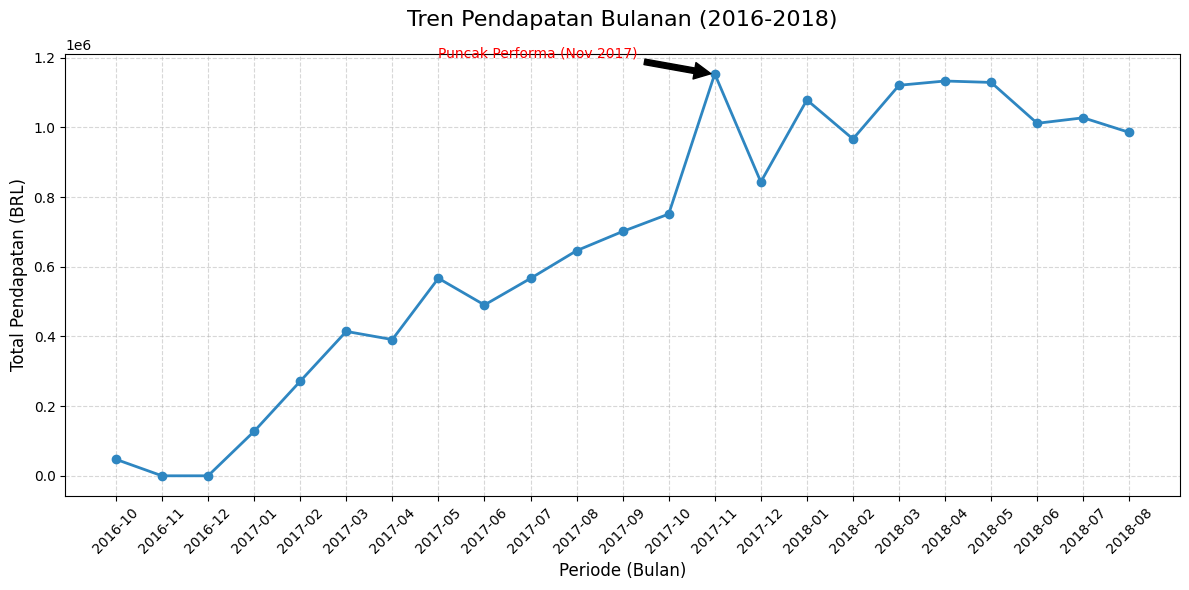

In [8]:
plot_df = monthly_revenue_agg.copy()
plot_df['order_date'] = plot_df['order_date'].dt.strftime('%Y-%m')

plt.figure(figsize=(12, 6))
plt.plot(
    plot_df['order_date'],
    plot_df['total_revenue'],
    marker='o',
    linewidth=2,
    color='#2E86C1'
)

plt.title("Tren Pendapatan Bulanan (2016-2018)", fontsize=16, pad=20)
plt.xlabel("Periode (Bulan)", fontsize=12)
plt.ylabel("Total Pendapatan (BRL)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

plt.annotate('Puncak Performa (Nov 2017)',
             xy=('2017-11', 1151882),
             xytext=('2017-05', 1200000),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, color='red')

plt.tight_layout()
plt.show()

**Insight:**
- Pertumbuhan Signifikan: Pendapatan perusahaan menunjukkan tren bullish (meningkat) yang sangat kuat sejak awal 2017.

- Peak Performance: Puncak pendapatan tertinggi terjadi pada November 2017 dengan angka BRL 1.151.882. Hal ini mengonfirmasi bahwa kampanye musiman sangat efektif.

- Retensi Pendapatan: Meskipun sempat melandai di awal 2018, angka pendapatan bulanan tidak pernah kembali ke level rendah tahun 2016, menunjukkan platform telah berhasil melakukan akuisisi user dalam jumlah besar.

### Pertanyaan Bisnis 2
Bagaimana pola penggunaan metode pembayaran pada tahun 2018 berdasarkan jumlah transaksi unik dan total nilai pembayaran, serta metode mana yang paling berkontribusi terhadap pendapatan?

/tmp/ipykernel_17270/3219352789.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


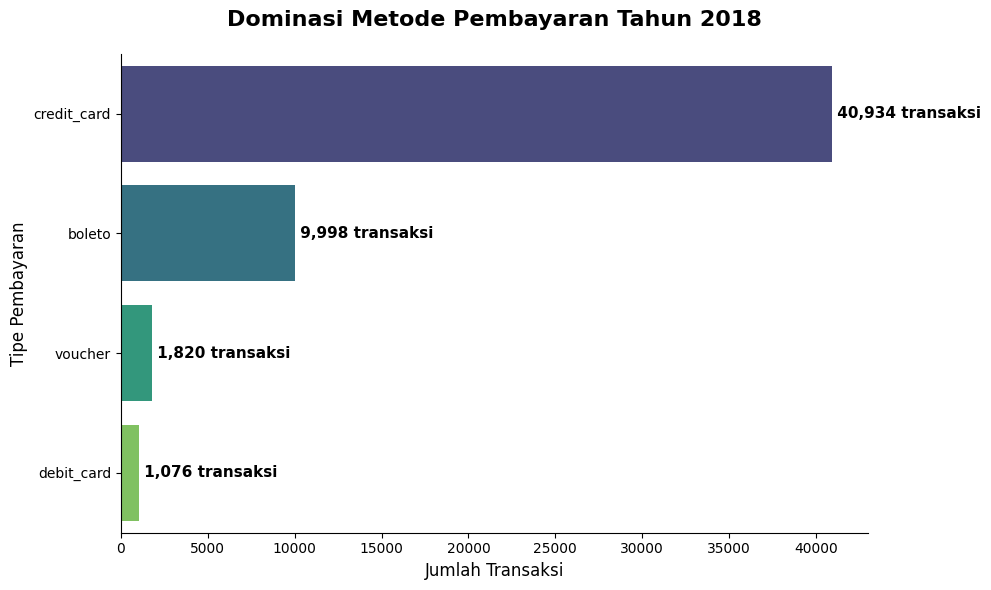

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="order_id",
    y="payment_type",
    data=payment_type_agg,
    palette="viridis"
)

plt.title("Dominasi Metode Pembayaran Tahun 2018", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Jumlah Transaksi", fontsize=12)
plt.ylabel("Tipe Pembayaran", fontsize=12)

for index, value in enumerate(payment_type_agg['order_id']):
    plt.text(value, index, f' {value:,} transaksi', va='center', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

**Insight:**
- Dominasi Pembayaran: Credit Card memegang kendali pasar dengan 40.934 transaksi. Ini menunjukkan bahwa mayoritas pelanggan lebih memilih fleksibilitas pembayaran (seperti cicilan).

- Kesenjangan Metode: Terdapat gap yang sangat jauh antara Kartu Kredit dengan Boleto (9.998) dan metode lainnya. Hal ini menandakan sistem pembayaran non-tunai berbasis kredit adalah penggerak utama volume transaksi di platform.

- Potensi yang Kurang Digali: Metode Debit Card sangat rendah penggunaannya. Ini bisa menjadi sinyal bahwa pelanggan mungkin merasa kurang aman atau kurang mendapatkan keuntungan (seperti promo/point) jika menggunakan kartu debit.

## Analisis Lanjutan (Opsional)

In [10]:
# --- RFM Analysis ---

# 1. Menghitung parameter RFM
rfm_df = main_df.groupby(by="customer_id", as_index=False).agg({
    "order_purchase_timestamp": "max", # Mengambil tanggal transaksi terakhir (Recency)
    "order_id": "nunique",             # Menghitung jumlah pesanan (Frequency)
    "payment_value": "sum"             # Menghitung total belanja (Monetary)
})

# 2. Menamai kolom agar lebih rapi
rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]

# 3. Menghitung Recency (hari)
recent_date = main_df["order_purchase_timestamp"].max()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)

# 4. Hapus kolom timestamp yang sudah tidak digunakan
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

print("--- Tabel RFM Analysis (Top 5 Customers by Monetary) ---")
display(rfm_df.sort_values(by="monetary", ascending=False).head())

--- Tabel RFM Analysis (Top 5 Customers by Monetary) ---


,customer_id,frequency,monetary,recency
8293,1617b1357756262bfa56ab541c47bc16,1,13664.08,333
89273,ec5b2ba62e574342386871631fafd3fc,1,7274.88,45
75240,c6e2731c5b391845f6800c97401a43a9,1,6929.31,562
92308,f48d464a0baaea338cb25f816991ab1f,1,6922.21,34
24067,3fd6777bbce08a352fddd04e4a7cc8f6,1,6726.66,461


**Insight:**
- Monetary (Nilai Transaksi Terbesar):

Pelanggan dengan ID 1617b1357756262bfa56ab541c47bc16 merupakan  pelanggan prioritas dengan total pembelanjaan mencapai BRL 13.664,08.

Kelima pelanggan teratas memiliki nilai transaksi yang sangat tinggi (di atas BRL 6.700), yang jauh melampaui rata-rata pelanggan lainnya.

- Frequency (Frekuensi Transaksi):

Temuan unik menunjukkan bahwa seluruh Top 5 spender tersebut hanya melakukan 1 kali transaksi (frequency = 1).

Analisis: Hal ini mengindikasikan bahwa platform kita berhasil menarik transaksi bernilai besar, namun belum berhasil menjaga loyalitas pelanggan tersebut untuk melakukan pembelian berulang (repeat order).

- Recency (Kapan Terakhir Belanja):

Terdapat rentang yang sangat jauh pada nilai Recency. Pelanggan ID f48d464a0baaea338cb25f816991ab1f masih tergolong aktif karena terakhir bertransaksi 34 hari yang lalu.

Sebaliknya, pelanggan ID c6e2731c5b391845f6800c97401a43a9 sudah tidak bertransaksi selama 562 hari. Ini adalah sinyal bahaya (Churn) karena pelanggan yang pernah belanja dalam jumlah sangat besar kini sudah tidak aktif lagi.

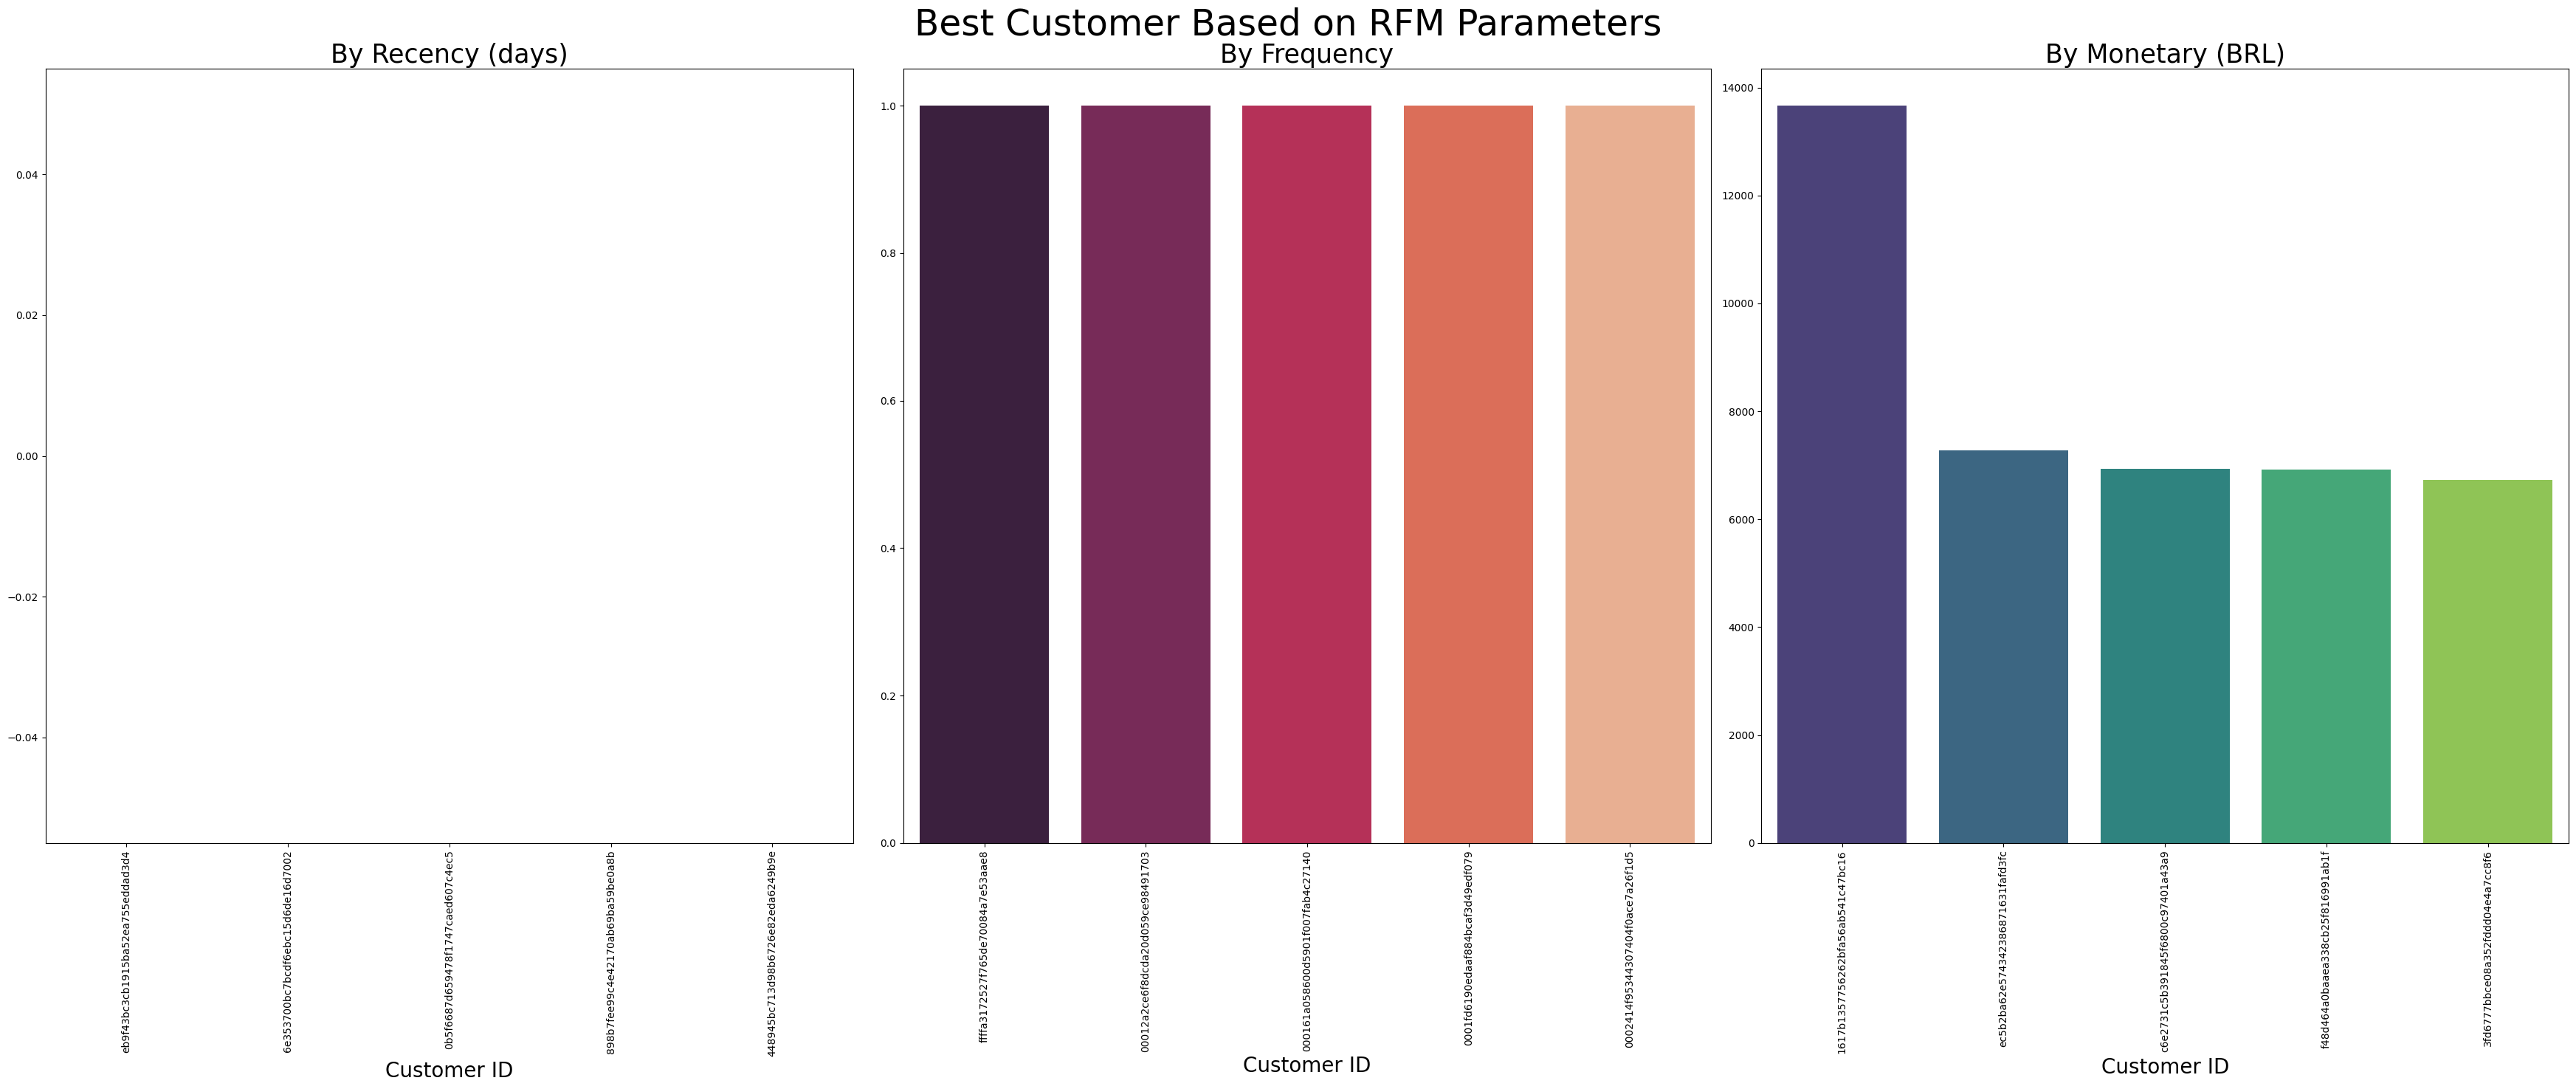

In [11]:
import warnings
warnings.filterwarnings("ignore")
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(35, 15))


# 1. Berdasarkan Recency (Semakin rendah harinya, semakin baik)
sns.barplot(y="recency", x="customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette="mako", ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("Customer ID", fontsize=20)
ax[0].set_title("By Recency (days)", loc="center", fontsize=25)
ax[0].tick_params(axis='x', rotation=90)

# 2. Berdasarkan Frequency (Semakin banyak pesanan, semakin baik)
sns.barplot(y="frequency", x="customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette="rocket", ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("Customer ID", fontsize=20)
ax[1].set_title("By Frequency", loc="center", fontsize=25)
ax[1].tick_params(axis='x', rotation=90)

# 3. Berdasarkan Monetary (Semakin besar uangnya, semakin baik)
sns.barplot(y="monetary", x="customer_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette="viridis", ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel("Customer ID", fontsize=20)
ax[2].set_title("By Monetary (BRL)", loc="center", fontsize=25)
ax[2].tick_params(axis='x', rotation=90)

plt.suptitle("Best Customer Based on RFM Parameters", fontsize=35)
plt.tight_layout()
plt.show()

**Insight:**
 1. Analisis Tren Pendapatan (Line Chart)
Insight: Pendapatan perusahaan menunjukkan tren kenaikan yang sangat stabil sejak awal 2017.

Puncak Performa: Sesuai tanda panah di grafik, November 2017 adalah "Golden Month" dengan pendapatan tertinggi mencapai BRL 1.151.882.

Kondisi 2018: Meskipun fluktuatif, rata-rata pendapatan bulanan di tahun 2018 tetap bertahan di level atas (sekitar BRL 1 juta), menunjukkan bisnis sudah dalam tahap stabil.

2. Analisis Metode Pembayaran (Bar Chart)
Dominasi: Credit Card adalah raja dengan 40.934 transaksi. Ini menunjukkan pelanggan sangat menyukai sistem cicilan atau kemudahan kartu kredit.

Kesenjangan: Ada jarak yang sangat jauh dengan Boleto (9.998). Sementara itu, Voucher dan Debit Card sangat jarang digunakan.

Rekomendasi: Perusahaan harus terus menjalin kerja sama dengan penyedia kartu kredit untuk promo cashback karena ini adalah sumber utama uang masuk.

3. Analisis RFM (Tiga Plot)
- Recency: Ada pelanggan yang baru saja bertransaksi (0 hari), yang artinya tim marketing berhasil menjaga aliran pelanggan baru.

- Frequency: Pada grafik tengah, semua nilainya 1.0. Artinya, pelanggan terbaik belum belanja untuk kedua kalinya

- Monetary: Pelanggan dengan ID 1617b1357756262bfa56ab541c47bc16 adalah penyumbang terbesar dengan nilai BRL 13.664.

In [12]:
# Simpan data untuk dashboard
main_df.to_csv("dashboard/main_data.csv", index=False)

## Conclusion

**Kesimpulan Pertanyaan 1 (Tren Pendapatan Bulanan):**
- Pendapatan bulanan menunjukkan tren kenaikan kuat sepanjang 2017 dan mencapai puncak pada November 2017.
- Pada 2018, pendapatan cenderung fluktuatif namun tetap berada pada level yang lebih tinggi dibanding fase awal pertumbuhan.
- Artinya, bisnis berhasil tumbuh, tetapi perlu strategi stabilisasi agar tidak terlalu bergantung pada momentum musiman.

**Kesimpulan Pertanyaan 2 (Metode Pembayaran):**
- Credit card mendominasi jumlah transaksi dan kontribusi nilai pembayaran pada 2018.
- Metode selain credit card berkontribusi jauh lebih rendah, menandakan ketergantungan kanal pembayaran yang tinggi.

**Rekomendasi Action Item:**
1. Fokuskan kampanye promosi 4-6 minggu sebelum bulan puncak historis untuk memaksimalkan revenue musiman.
2. Buat insentif untuk metode pembayaran non-dominan agar distribusi kanal pembayaran lebih seimbang.
3. Jalankan program retensi untuk segmen pelanggan bernilai tinggi (monetary tinggi, frequency rendah) berdasarkan hasil RFM.